The purpose of this notebook is to take a deeper look into the model I created based on the tweets looked at for San Francisco June 2018 to December 2018.

In [1]:
from datetime import datetime
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
# Load the count vector, the term frequency, the LDA model, and the topic assignment.
fp = '../scripts/'
cv = load(fp+'cv.joblib') # count vector
tf = load(fp+'tf.joblib') # term frequency
lda = load(fp+'lda.joblib') # latent dirichlet allocation
ta = load(fp+'topic_assignment.joblib') # ta for topic assignment

In [2]:
# Need to load the pseudo docs for reference
def load_data():
    """
    This function takes care of loading data, returning a dataframe
    with the tweets that we want to look at.

    If you are going to change anything on this file, change it here.
    """
    try:
        months = ['05','06','07','08','09','10','11','12']
        all_df = []
        for m in months:
            all_df.append(pd.read_csv('../data/san_francisco/2018-'+m+'.csv'))
       # Concatenate all dataframes into one DF. 
        all_df = pd.concat(all_df)
        return all_df
    except:
        print("Files not found")

def format_data(data):
    """
    Add special formatting instructions here
    The output of this function should be the pseudo docs that will be read
    by the LDA function.
    """
    data = data.dropna()
    # not_date = [d for d in all_df['created_at'] if type(d) ==float]
    data['date'] = [datetime.strptime(d,'%Y-%m-%d %H:%M:%S').date() for d in data['created_at']]
    pseudo_docs = pd.pivot_table(data,values="text",index="date",aggfunc=" ".join)
    # Only output the docs
    docs = pseudo_docs['text']
    return docs

data = load_data()
# Format the data - this should 
# organize the words in whatever form we want
# for running through LDA.
pseudo_docs = format_data(data)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:34: DtypeWarning: Columns (0,1) have mixed types.Specify dtype option on import or set low_memory=False.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


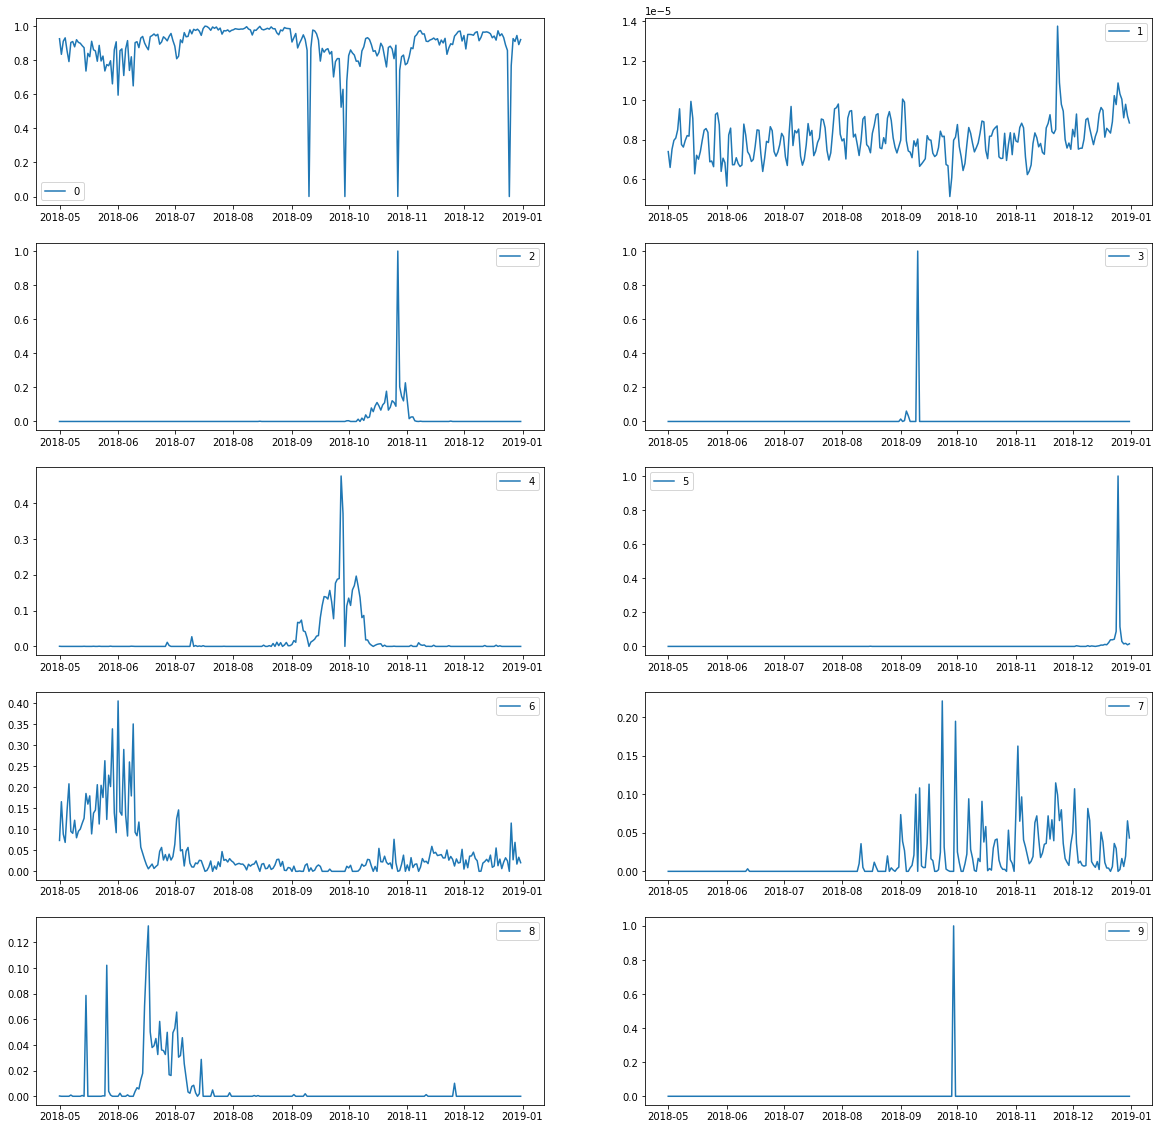

In [7]:
# Let's see if there is a trend over time for these topics
plt.figure(figsize=(20,20))
for i, t in enumerate(ta.T):
    plt.subplot(5,2, i+1)
    plt.plot(pseudo_docs.index, t, label=i)
    plt.legend()

In [9]:
import numpy as np
feature_names = cv.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print("Topic", idx," ".join(feature_names[i] for i in np.argsort(topic)[-20:]))

Topic 0 winter nazi nb senate rd fraud bernie border traitor eb sb climate ballot sunny mueller fog partly cloudy humidity lo
Topic 1 baste favela etat sunmi firewire coddled vilnius vishnu danita citibike authorizing revives decompressing emre rhombus baggs wojcicki revitalize hottttt haagen
Topic 2 caravan machado rondo pumpkin rhetoric midterm spooky yard candy klay curry inning lakers boston oct saudi sox costume dodger halloween
Topic 3 nicki sunny mon serena humidity aptos lo kaepernick packer woodward kavanaugh qb sep gruden khalil aaron rodgers raider mack nike
Topic 4 graham garland nominee collins testimony witness oct halloween allegation october senate rape scotus brett sep supreme fbi assault ford kavanaugh
Topic 5 rico wrapping bernie border airpods syria pelosi birdbox nancy tanker aquaman mattis lakers shutdown raider cargo dec xmas eve merry
Topic 6 kerr durant mvp kanye houston june parade bron harden ref foul jr draymond rocket klay dub cavs kd steph curry
Topic 7 ma

In [21]:
lda.transform(tf[0])
tf[0]

<1x44842 sparse matrix of type '<class 'numpy.int64'>'
	with 7645 stored elements in Compressed Sparse Row format>

In [24]:
cv.decode(tf[0])

<1x44842 sparse matrix of type '<class 'numpy.int64'>'
	with 7645 stored elements in Compressed Sparse Row format>

In [28]:
test_tweet = "lung hurt"
tt = test_tweet.split(" ")

cv.transform(tt)
lda.transform(cv.transform(tt))

array([[0.05001957, 0.05      , 0.05000346, 0.05      , 0.54997161,
        0.05      , 0.05      , 0.05      , 0.05      , 0.05000536],
       [0.1       , 0.1       , 0.1       , 0.1       , 0.1       ,
        0.1       , 0.1       , 0.1       , 0.1       , 0.1       ]])

## Looking at more topics

In [3]:
# Load the count vector, the term frequency, the LDA model, and the topic assignment.
fp = '../scripts/'
cv = load(fp+'cv.joblib') # count vector
tf = load(fp+'tf.joblib') # term frequency
lda = load(fp+'lda.joblib') # latent dirichlet allocation
ta = load(fp+'topic_assignment.joblib') # ta for topic assignment

In [4]:
ta.shape

(245, 20)

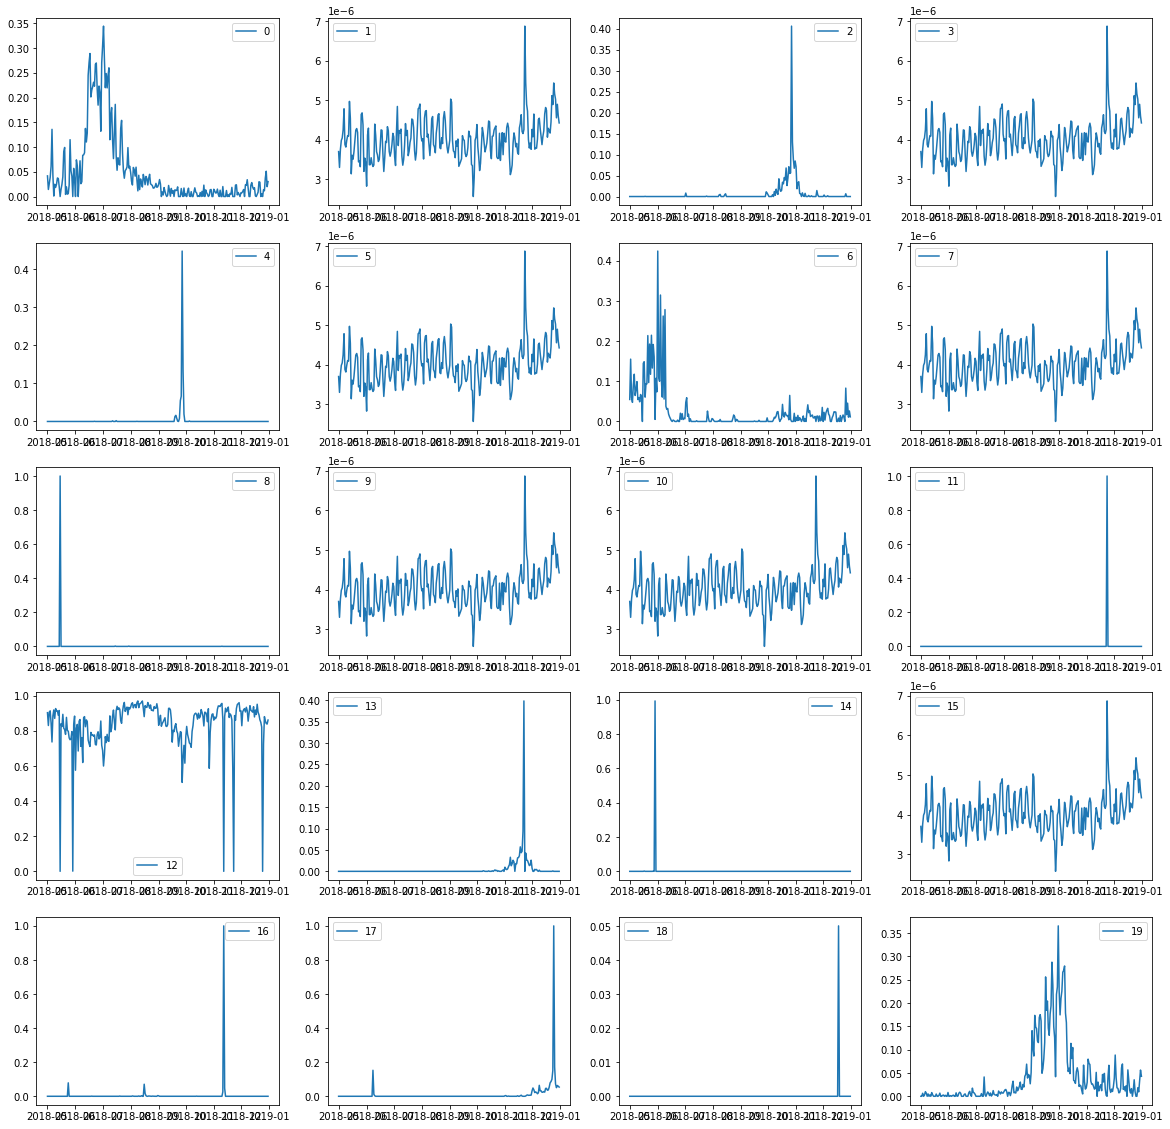

In [5]:
# Let's see if there is a trend over time for these topics
plt.figure(figsize=(20,20))
for i, t in enumerate(ta.T):
    plt.subplot(5,4, i+1)
    plt.plot(pseudo_docs.index, t, label=i)
    plt.legend()

In [6]:
import numpy as np
feature_names = cv.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print("Topic", idx," ".join(feature_names[i] for i in np.argsort(topic)[-20:]))

Topic 0 boogie brazil croatia patchy silver korea fog lo jun soccer germany england france border parade jul firework pride lakers july
Topic 1 forgone forgotten fork forked forking formative 𝙔𝙈 forlorn formal formality formally format formation subsystem voyeur sacrosanct quash vl instagramming shmoplife
Topic 2 raider spooky curry machado pumpkin kershaw oct rhetoric rondo candy caravan inning klay yard boston sox lakers costume dodger halloween
Topic 3 forgone forgotten fork forked forking formative 𝙔𝙈 forlorn formal formality formally format formation subsystem voyeur sacrosanct quash vl instagramming shmoplife
Topic 4 senate christine grassley allegation blasey carter rape cosby iot salesforce wayne supreme testimony graham brett dreamforce assault fbi ford kavanaugh
Topic 5 forgone forgotten fork forked forking formative 𝙔𝙈 forlorn formal formality formally format formation subsystem voyeur sacrosanct quash vl instagramming shmoplife
Topic 6 facist complicit resignation homophobi